In [1]:
!pip install numpy pandas matplotlib scikit-learn tensorflow opencv-python

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
np.random.seed(42)

size = 300
living_area = np.random.randint(500, 4000, size)
price = living_area * 120 + np.random.randint(-50000, 50000, size)
expensive = (price > 250000).astype(int)

housing_df = pd.DataFrame({
    "LivingArea": living_area,
    "Price": price,
    "Expensive": expensive
})

housing_df.head()

,LivingArea,Price,Expensive
0,3674,474643,1
1,1360,121880,0
2,1794,250176,1
3,1630,229479,0
4,1595,212695,0


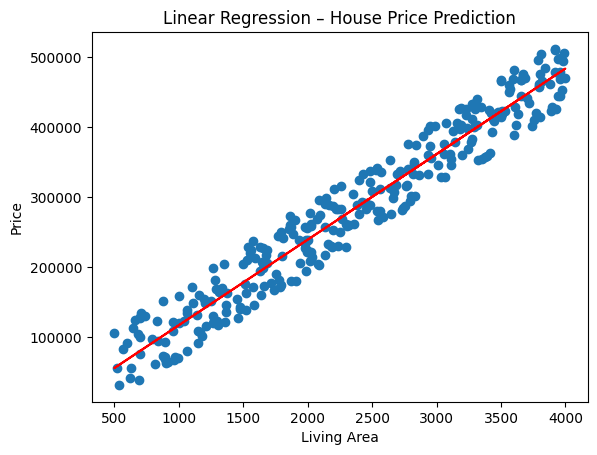

Prediction for 2000 sq ft: [239257.92913278]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [5]:
from sklearn.linear_model import LinearRegression

X = housing_df[["LivingArea"]]
y = housing_df["Price"]

lr = LinearRegression()
lr.fit(X, y)

# Plot
plt.scatter(X, y)
plt.plot(X, lr.predict(X), color="red")
plt.xlabel("Living Area")
plt.ylabel("Price")
plt.title("Linear Regression – House Price Prediction")
plt.show()

print("Prediction for 2000 sq ft:", lr.predict([[2000]]))

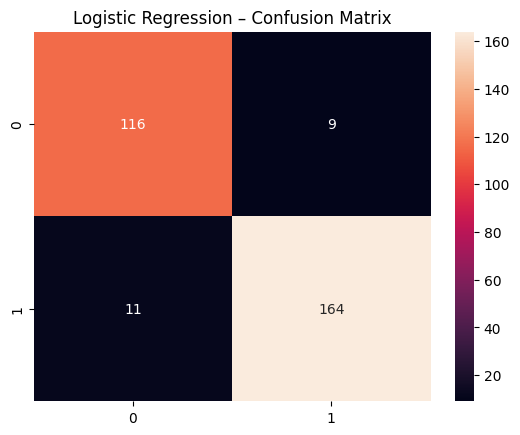

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

X = housing_df[["LivingArea"]]
y = housing_df["Expensive"]

logr = LogisticRegression()
logr.fit(X, y)

y_pred = logr.predict(X)
cm = confusion_matrix(y, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Logistic Regression – Confusion Matrix")
plt.show()